In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

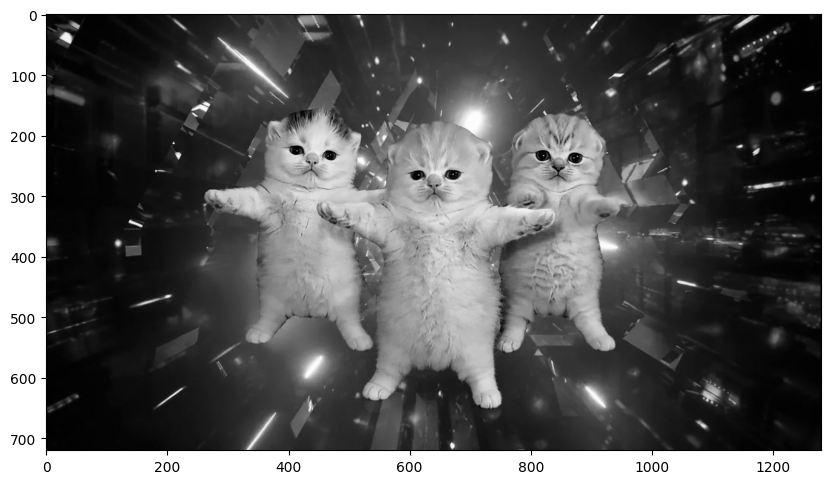

In [51]:
image = cv2.imread("/content/kittens.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 6))
plt.imshow(image, cmap="gray")
plt.show()

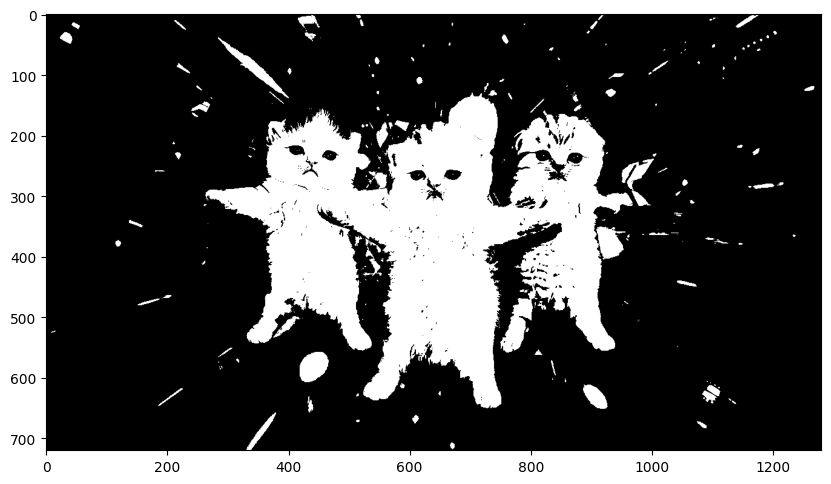

In [50]:
_, binary = cv2.threshold(
    image,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(10, 6))
plt.imshow(binary, cmap='gray')
plt.show()

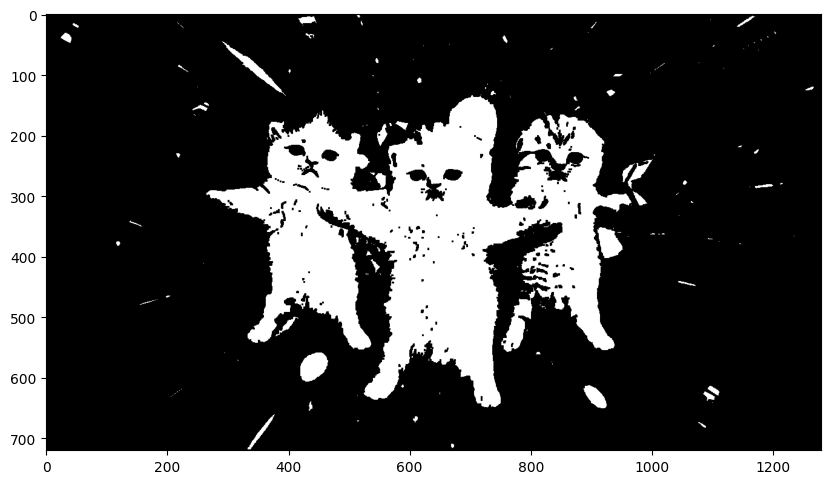

In [61]:
kernel = np.ones((3, 3), dtype=np.uint8)

start = time.perf_counter()

eroded_cv = cv2.erode(
    binary,
    kernel,
    iterations=1,
    borderType=cv2.BORDER_CONSTANT,
    borderValue=0
)

end = time.perf_counter()

time_cv = end - start

plt.figure(figsize=(10, 6))
plt.imshow(eroded_cv, cmap="gray")
plt.show()

In [62]:
def erosion_manual(image):
    height, width = image.shape

    padded = np.pad(
        image,
        pad_width=1,
        mode='constant',
        constant_values=0
    )

    result = np.zeros_like(image)

    for y in range(height):
        for x in range(width):

            region = padded[y:y+3, x:x+3]

            if np.all(region == 255):
                result[y, x] = 255
            else:
                result[y, x] = 0

    return result

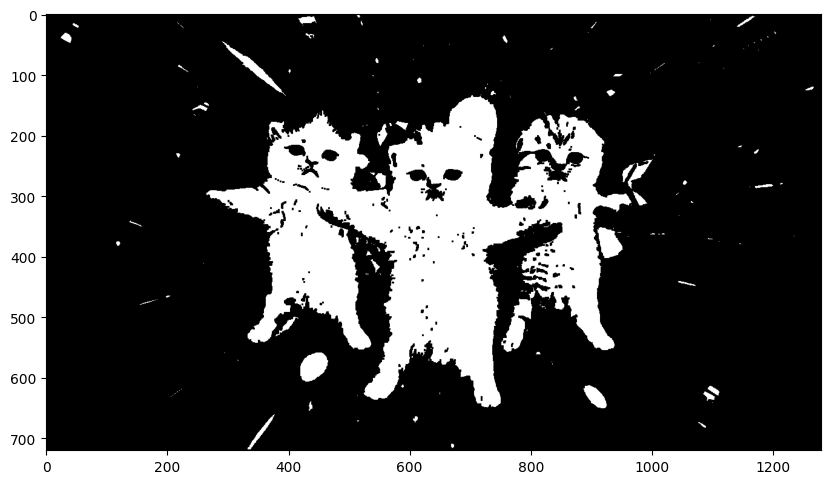

In [63]:
start = time.perf_counter()

eroded_manual = erosion_manual(binary)

end = time.perf_counter()

time_manual = end - start

plt.figure(figsize=(10, 6))
plt.imshow(eroded_manual, cmap="gray")
plt.show()

Количество отличающихся пикселей: 0


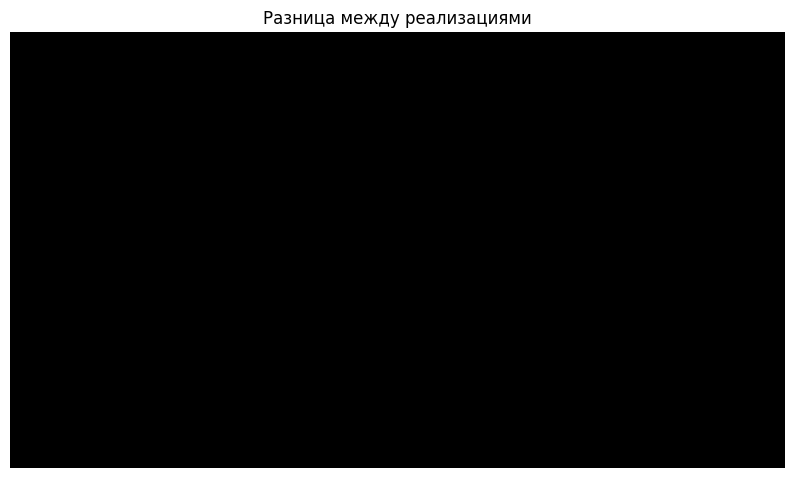

In [64]:
difference = cv2.absdiff(eroded_cv, eroded_manual)

different_pixels = np.count_nonzero(difference)

print("Количество отличающихся пикселей:", different_pixels)

plt.figure(figsize=(10, 6))
plt.imshow(difference, cmap="gray")
plt.title("Разница между реализациями")
plt.axis("off")
plt.show()

In [46]:
print(f"OpenCV: {time_cv:.6f} сек")
print(f"Ручная версия: {time_manual:.6f} сек")

print(f"OpenCV быстрее в {time_manual / time_cv:.6f} раз")

OpenCV: 0.001343 сек
Ручная версия: 6.764209 сек
OpenCV быстрее в 5037.537889 раз
